In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

# Use high precision for stability (VERY important for spectral methods)
torch.set_default_dtype(torch.float64)

In [2]:
def chebyshev_cgl(N):
    """
    Generate Chebyshev-Gauss-Lobatto points in [-1,1]
    
    N = number of intervals
    returns N+1 points
    """
    j = torch.arange(0, N+1)
    x = torch.cos(torch.pi * j / N)
    return x

In [3]:
def chebyshev_diff_matrix(N):
    """
    Build differentiation matrix D such that:
    u_x ≈ D u
    """
    x = chebyshev_cgl(N)
    
    c = torch.ones(N+1)
    c[0] = 2.0
    c[-1] = 2.0
    
    X = x.unsqueeze(0)
    dX = X.T - X
    
    C = c.unsqueeze(0)
    C_ratio = C.T / C
    
    i = torch.arange(N+1)
    sign = (-1.0) ** (i.unsqueeze(0) + i.unsqueeze(1))
    
    # avoid division by zero
    dX = dX + torch.eye(N+1)
    
    D = C_ratio * sign / dX
    
    # fix diagonal entries
    D = D - torch.diag(torch.sum(D, dim=1))
    
    return x, D

In [4]:
def build_A(D, bc_weight=1.0):
    """
    Build full operator A such that:
    r = A u - f
    """
    
    # second derivative
    D2 = D @ D
    
    # PDE part: -u''
    A_pde = -D2
    
    # Boundary conditions
    Np1 = D.shape[0]
    A_bc = torch.zeros(2, Np1)
    
    A_bc[0, 0] = bc_weight       # u(-1)
    A_bc[1, -1] = bc_weight      # u(1)
    
    # Combine
    A = torch.cat([A_pde, A_bc], dim=0)
    
    return A

In [5]:
def chebyshev_basis(x, K):
    """
    Build basis matrix Phi
    
    Phi[i,k] = T_k(x_i)
    """
    
    theta = torch.arccos(x)
    k = torch.arange(0, K)
    
    Phi = torch.cos(theta.unsqueeze(1) * k.unsqueeze(0))
    
    return Phi

In [6]:
import torch.nn as nn

class CoeffNet(nn.Module):
    def __init__(self, K):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, K)
        )
    
    def forward(self):
        # dummy input (we just want coefficients)
        x = torch.ones(1, 1)
        return self.net(x).view(-1)

In [7]:
def build_B(model):
    """
    Build Jacobian:
    B = dc/dθ
    
    Shape:
    (K, P)
    """
    
    c = model()

    if c.dim() == 0:
        c = c.unsqueeze(0)

    K = c.shape[0]
    
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    
    B = torch.zeros(K, P)
    
    for k in range(K):
        model.zero_grad()
        c[k].backward(retain_graph=True)
        
        grads = []
        for p in params:
            grads.append(p.grad.view(-1))
        
        B[k] = torch.cat(grads)
    
    return B

In [8]:
def compute_residual(model, A, Phi, f):
    """
    Compute:
    r = A u - f
    """
    
    c = model()
    u = Phi @ c
    
    r = A @ u - f
    
    return r, u, c

In [9]:
# Problem setup

N = 20
K = 20

# Grid + differentiation
x, D = chebyshev_diff_matrix(N)

# Build operator A
A = build_A(D, bc_weight=10.0)

# Basis
Phi = chebyshev_basis(x, K)

# RHS f (example)
f = (torch.pi**2) * torch.sin(torch.pi * x)

# Extend f to match A (important!)
f = torch.cat([f, torch.zeros(2)])

model_smw = CoeffNet(K)

# Method 1: Direct Gauss–Newton using SMW Identity

We solve:

    (J^T J + μI) Δθ = -J^T r

Using structure:

    J = A Φ B

So:

    J^T J = B^T G B
    G = Φ^T A^T A Φ

Instead of solving:

    (B^T G B + μI)

we apply SMW:

    (μI + B^T G B)^{-1}
    = (1/μ)[I - B^T (μ G^{-1} + B B^T)^{-1} B]

Final update:

    Δθ = -(1/μ)[I - B^T (μ G^{-1} + B B^T)^{-1} B] B^T Φ^T A^T r

Goal of this section:
- Implement this formula step-by-step
- Keep everything explicit and understandable

# Method 1 with HODLR

We compute:

    G = Φ^T A^T A Φ

But we DO NOT use dense multiplication.

Instead:
- Use HODLR for A v
- Compute A Φ column-by-column

Pipeline:

1. For each basis column Φ_k:
       compute A Φ_k using HODLR

2. Stack results → AΦ

3. Compute:
       G = (AΦ)^T (AΦ)

This avoids O(N^2 K) cost and uses fast matvec.

In [10]:
class RectangularHODLR:
    def __init__(self, n_rows, n_cols, block_fn, x_coords, p=8, max_level=4, leaf_size=64):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.block_fn = block_fn
        self.x_coords = x_coords   # ✅ pass coordinates explicitly
        self.p = p
        self.max_level = max_level
        self.leaf_size = leaf_size
        
        self.blocks = []
        self._build(0, self.n_rows, 0, self.n_cols, level=0)

    # ---------------- CHEBYSHEV UTILS ----------------
    def chebyshev_points(self, p):
        k = np.arange(p)
        return np.cos((2*k+1)*np.pi/(2*p))

    def chebyshev_polynomials(self, x, p):
        x = np.asarray(x)
        T = np.zeros((len(x), p))

        T[:,0] = 1.0
        if p > 1:
            T[:,1] = x

        for n in range(2,p):
            T[:,n] = 2*x*T[:,n-1] - T[:,n-2]

        return T

    def scale_to_minus1_1(self, x, a, b):
        return (2*x - (a+b)) / (b-a)

    def build_interpolation_matrix(self, x_block, p):
        a,b = x_block.min(), x_block.max()

        x_scaled = self.scale_to_minus1_1(x_block, a, b)

        T = self.chebyshev_polynomials(x_scaled, p)

        t = self.chebyshev_points(p)
        Tt = self.chebyshev_polynomials(t, p)

        gamma = np.ones(p)
        gamma[0] = 0.5
        W = (2/p)*gamma

        return T @ (W[:,None]*Tt.T)
    
    def interpolate_matrix(self, xr, xc):
        S = np.zeros((len(xr), len(xc)))  # should be (p, p)

        for i in range(len(xr)):
            for j in range(len(xc)):
                
                # map coordinates → nearest indices
                ii = np.argmin(np.abs(self.x_coords - xr[i]))
                jj = np.argmin(np.abs(self.x_coords - xc[j]))
                
                S[i, j] = self.block_fn([ii], [jj])[0, 0]

        return S

    # ---------------- BUILD TREE ----------------
    def _build(self, r0, r1, c0, c1, level):
        is_far = (r1 <= c0) or (c1 <= r0)

        # -------- LOW-RANK (CHEBYSHEV) --------
        if is_far and level > 0:
            row_idx = np.arange(r0, r1)
            col_idx = np.arange(c0, c1)

            # ✅ use REAL coordinates (FIXED)
            x_row = self.x_coords[r0:r1]
            x_col = self.x_coords[c0:c1]

            # interpolation matrices
            U = self.build_interpolation_matrix(x_row, self.p)
            V = self.build_interpolation_matrix(x_col, self.p)

            # Chebyshev nodes
            t = self.chebyshev_points(self.p)

            ar, br = x_row.min(), x_row.max()
            ac, bc = x_col.min(), x_col.max()

            xr = 0.5*(br-ar)*t + 0.5*(br+ar)
            xc = 0.5*(bc-ac)*t + 0.5*(bc+ac)

            # S = self.block_fn(xr_idx, xc_idx)
            # S = self.block_fn(row_idx[:self.p], col_idx[:self.p])
            S = self.interpolate_matrix(xr, xc)
            
            ##
            # def kernel_matrix(xr, xc):
            #     return 1.0 / np.abs(xr[:, None] - xc[None, :])

            # S = kernel_matrix(xr, xc)
            # S[np.isinf(S)] = 0.0
            ##

            self.blocks.append(('cheb_lowrank', (r0,r1),(c0,c1), U, S, V))

        # -------- DENSE BLOCK --------
        elif level >= self.max_level or (r1 - r0) <= self.leaf_size:
            mat = self.block_fn(np.arange(r0, r1), np.arange(c0, c1))
            self.blocks.append(('dense', (r0, r1), (c0, c1), mat))

        # -------- RECURSION --------
        else:
            rmid = (r0 + r1) // 2
            cmid = (c0 + c1) // 2

            self._build(r0, rmid, c0, cmid, level + 1)
            self._build(r0, rmid, cmid, c1, level + 1)
            self._build(rmid, r1, c0, cmid, level + 1)
            self._build(rmid, r1, cmid, c1, level + 1)

    # ---------------- MATVEC ----------------
    def matvec(self, v):
        y = np.zeros(self.n_rows)
        for kind, r_range, c_range, *data in self.blocks:
            r0, r1 = r_range
            c0, c1 = c_range
            if kind == 'dense':
                y[r0:r1] += data[0] @ v[c0:c1]
            else:
                U, S, V = data
                y[r0:r1] += U @ (S @ (V.T @ v[c0:c1]))
        return y

In [11]:
# Convert A → numpy for HODLR
A_np = A.detach().cpu().numpy()

def A_block(row_idx, col_idx):
    return A_np[np.ix_(row_idx, col_idx)]

# Build HODLR
H = RectangularHODLR(
        n_rows=A.shape[0],
        n_cols=A.shape[1],
        block_fn=A_block,
        x_coords=x,   # ✅ NEW
        p=16,
        max_level=4
    )

In [12]:
def hodlr_matvec(H, v):
    """
    Compute A v using HODLR
    
    Input:
        v (torch) shape: (N+1,)
    
    Output:
        y (torch) shape: (N+3,)
    """
    
    v_np = v.detach().cpu().numpy()
    y_np = H.matvec(v_np)
    
    return torch.from_numpy(y_np)

In [13]:
def compute_A_Phi_hodlr(H, Phi):
    """
    Compute AΦ using HODLR matvec
    
    Inputs:
        H   : HODLR object (represents A)
        Phi : (N+1, K)
    
    Output:
        APhi : (N+3, K)
    """
    
    K = Phi.shape[1]
    APhi_cols = []
    
    for k in range(K):
        phi_k = Phi[:, k]                 # (N+1,)
        
        # Apply A using HODLR
        A_phi_k = hodlr_matvec(H, phi_k)  # (N+3,)
        
        APhi_cols.append(A_phi_k)
    
    APhi = torch.stack(APhi_cols, dim=1)  # (N+3, K)
    
    return APhi

In [14]:
def compute_G_from_APhi(APhi):
    """
    Compute:
        G = (AΦ)^T (AΦ)
    
    Input:
        APhi : (N+3, K)
    
    Output:
        G : (K, K)
    """
    
    G = APhi.T @ APhi
    
    return G

In [15]:
def hodlr_matvec_transpose(H, v):
    """
    Compute y = A^T v using HODLR
    
    Input:
        v : (N+3,)
    
    Output:
        y : (N+1,)
    """
    
    v_np = v.detach().cpu().numpy()
    y = np.zeros(H.n_cols)
    
    for kind, r_range, c_range, *data in H.blocks:
        r0, r1 = r_range
        c0, c1 = c_range
        
        if kind == 'dense':
            mat = data[0]
            y[c0:c1] += mat.T @ v_np[r0:r1]
        
        else:
            U, S, V = data
            # (U S V)^T = V^T S U^T
            y[c0:c1] += V @ (S.T @ (U.T @ v_np[r0:r1]))
    
    return torch.from_numpy(y)

In [16]:
def compute_rhs_hodlr(H, Phi, B, r):
    """
    Compute:
        g = B^T Φ^T A^T r
    
    Inputs:
        H   : HODLR (represents A)
        Phi : (N+1, K)
        B   : (K, P)
        r   : (N+3,)
    
    Output:
        g : (P,)
    """
    
    # Step 1: A^T r
    At_r = hodlr_matvec_transpose(H, r)   # (N+1,)
    
    # Step 2: Φ^T (A^T r)
    PhiT_At_r = Phi.T @ At_r              # (K,)
    
    # Step 3: B^T (...)
    g = B.T @ PhiT_At_r                  # (P,)
    
    return g

In [17]:
model = model_smw

B = build_B(model)
r, _, _ = compute_residual(model, A, Phi, f)

g = compute_rhs_hodlr(H, Phi, B, r)

print(g.shape)

torch.Size([644])


In [18]:
def solve_smw(G, B, g, mu):
    """
    Solve using SMW:

    Δθ = -(1/μ)[I - B^T (μ G^{-1} + B B^T)^{-1} B] g

    Inputs:
        G : (K, K)
        B : (K, P)
        g : (P,)
        mu: scalar

    Output:
        delta_theta : (P,)
    """
    G = G + 1e-3 * torch.eye(G.shape[0])  # regularization for stability
    
    # Step 1: G^{-1}
    G_inv = torch.linalg.inv(G)   # (K, K)
    
    # Step 2: BB^T
    BBt = B @ B.T                # (K, K)
    
    # Step 3: Small system
    M_small = mu * G_inv + BBt   # (K, K)
    
    M_small_inv = torch.linalg.inv(M_small)
    
    # Step 4: B g
    Bg = B @ g                   # (K,)
    
    # Step 5: Middle term
    middle = M_small_inv @ Bg    # (K,)
    
    # Step 6: B^T (...)
    B_middle = B.T @ middle      # (P,)
    
    # Step 7: Final SMW formula
    delta_theta = -(1.0 / mu) * (g - B_middle)
    
    return delta_theta

In [19]:
def apply_update(model, delta_theta, lr=0.01):
    """
    Update NN parameters:
        θ ← θ + lr * Δθ
    """
    
    params = list(model.parameters())
    
    idx = 0
    for p in params:
        numel = p.numel()
        
        update = delta_theta[idx:idx+numel].view_as(p)
        p.data += lr * update
        
        idx += numel

In [20]:
def train_smw_hodlr(model, H, Phi, A, f, steps=20, lam=1e-2):
    
    losses = []
    
    for i in range(steps):
        
        # Step 1: Build B
        B = build_B(model)   # (K, P)
        
        # Step 2: Residual
        r, u, c = compute_residual(model, A, Phi, f)
        
        loss = torch.norm(r)
        losses.append(loss.item())
        
        print(f"[SMW-HODLR] Iter {i}, Loss: {loss.item():.4e}")
        
        # Step 3: Compute AΦ (HODLR)
        APhi = compute_A_Phi_hodlr(H, Phi)
        
        # Step 4: Compute G
        G = compute_G_from_APhi(APhi)
        
        # Step 5: Compute RHS g
        g = compute_rhs_hodlr(H, Phi, B, r)
        
        # Step 6: Compute μ
        mu = lam * torch.max(torch.diag(G))
        mu = lam  # alternative: fixed μ
        
        # Step 7: Solve SMW
        delta_theta = solve_smw(G, B, g, mu)
        
        # Step 8: Update
        apply_update(model, delta_theta)
    
    return losses

In [21]:
# Fresh model
model_smw = CoeffNet(K)

losses = train_smw_hodlr(
    model_smw,
    H,
    Phi,
    A,
    f,
    steps=2000
)

[SMW-HODLR] Iter 0, Loss: 9.0147e+03
[SMW-HODLR] Iter 1, Loss: 8.9244e+03
[SMW-HODLR] Iter 2, Loss: 8.8349e+03
[SMW-HODLR] Iter 3, Loss: 8.7463e+03
[SMW-HODLR] Iter 4, Loss: 8.6586e+03
[SMW-HODLR] Iter 5, Loss: 8.5719e+03
[SMW-HODLR] Iter 6, Loss: 8.4859e+03
[SMW-HODLR] Iter 7, Loss: 8.4008e+03
[SMW-HODLR] Iter 8, Loss: 8.3166e+03
[SMW-HODLR] Iter 9, Loss: 8.2332e+03
[SMW-HODLR] Iter 10, Loss: 8.1507e+03
[SMW-HODLR] Iter 11, Loss: 8.0690e+03
[SMW-HODLR] Iter 12, Loss: 7.9881e+03
[SMW-HODLR] Iter 13, Loss: 7.9081e+03
[SMW-HODLR] Iter 14, Loss: 7.8288e+03
[SMW-HODLR] Iter 15, Loss: 7.7503e+03
[SMW-HODLR] Iter 16, Loss: 7.6726e+03
[SMW-HODLR] Iter 17, Loss: 7.5957e+03
[SMW-HODLR] Iter 18, Loss: 7.5197e+03
[SMW-HODLR] Iter 19, Loss: 7.4443e+03
[SMW-HODLR] Iter 20, Loss: 7.3697e+03
[SMW-HODLR] Iter 21, Loss: 7.2958e+03
[SMW-HODLR] Iter 22, Loss: 7.2227e+03
[SMW-HODLR] Iter 23, Loss: 7.1503e+03
[SMW-HODLR] Iter 24, Loss: 7.0787e+03
[SMW-HODLR] Iter 25, Loss: 7.0078e+03
[SMW-HODLR] Iter 26, L

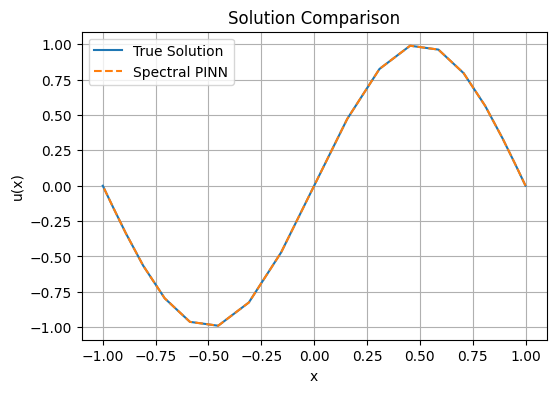

In [22]:
# True solution (depends on your PDE choice)
u_true = torch.sin(torch.pi * x)

# Predicted solution from model
with torch.no_grad():
    c = model_smw()          # use trained model
    u_pred = Phi @ c

# Move to numpy
x_np = x.detach().cpu().numpy()
u_true_np = u_true.detach().cpu().numpy()
u_pred_np = u_pred.detach().cpu().numpy()

# Plot: True vs Predicted
plt.figure(figsize=(6,4))
plt.plot(x_np, u_true_np, label="True Solution")
plt.plot(x_np, u_pred_np, '--', label="Spectral PINN")

plt.legend()
plt.title("Solution Comparison")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid()
plt.show()

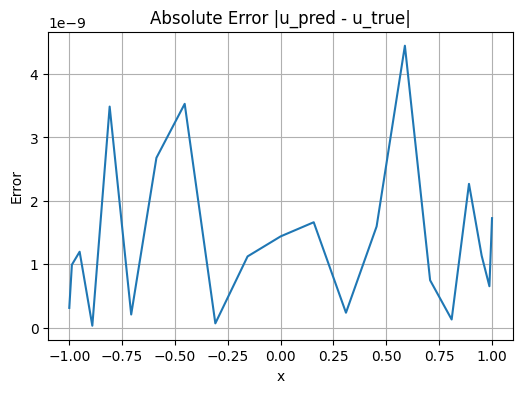

In [23]:
# Absolute error
error = torch.abs(u_pred - u_true)
error_np = error.detach().cpu().numpy()

plt.figure(figsize=(6,4))
plt.plot(x_np, error_np)

plt.title("Absolute Error |u_pred - u_true|")
plt.xlabel("x")
plt.ylabel("Error")
plt.grid()
plt.show()

In [24]:
# Relative L2 error
l2_error = torch.norm(u_pred - u_true) / torch.norm(u_true)

print("Relative L2 Error:", l2_error.item())

Relative L2 Error: 3.0659175421584102e-09


## refactoring the method 1

In [25]:
def setup_problem(N):
    """
    Build A, Phi, f for given N
    """
    
    K = max(10, min(40, N//3)) # important scaling
    
    # Grid
    x, D = chebyshev_diff_matrix(N)
    
    # Operator
    A = build_A(D, bc_weight=10.0)
    
    # Basis
    Phi = chebyshev_basis(x, K)
    
    # Correct RHS
    f = (torch.pi**2) * torch.sin(torch.pi * x)
    f = torch.cat([f, torch.zeros(2)])
    
    return x, A, Phi, f, K

In [26]:
def build_hodlr(A, x, p=16):

    A_np = A.detach().cpu().numpy()

    def A_block(row_idx, col_idx):
        return A_np[np.ix_(row_idx, col_idx)]

    # 🔥 ADD THIS (VERY IMPORTANT)
    x_coords = x.detach().cpu().numpy()
    x_coords = np.concatenate([x_coords, [x_coords[0], x_coords[-1]]])

    max_level = int(np.ceil(np.log2(max(A.shape) / p)))

    H = RectangularHODLR(
        n_rows=A.shape[0],
        n_cols=A.shape[1],
        block_fn=A_block,
        x_coords=x_coords,   # ✅ NEW
        p=p,
        max_level=max_level
    )

    return H

In [27]:
def train_method_1(model, H, Phi, A, f, steps=800, lam=1e-3):
    
    losses = []
    
    for i in range(steps):
        
        # B
        B = build_B(model)
        
        # Residual
        r, u, c = compute_residual(model, A, Phi, f)
        
        loss = torch.norm(r)
        losses.append(loss.item())
        
        # AΦ (HODLR)
        APhi = compute_A_Phi_hodlr(H, Phi)
        
        # G
        G = compute_G_from_APhi(APhi)
        
        # RHS
        g = compute_rhs_hodlr(H, Phi, B, r)
        
        # μ (correct version)
        mu = lam * torch.max(torch.diag(G))
        mu = lam
        
        # SMW solve
        delta_theta = solve_smw(G, B, g, mu)
        
        # Update
        apply_update(model, delta_theta, lr=0.1)
    
    return losses, model

In [28]:
def run_method_1(N, steps=800):
    
    # Setup
    x, A, Phi, f, K = setup_problem(N)
    
    # Model
    model = CoeffNet(K)
    
    # Build HODLR
    t0 = time.time()
    H = build_hodlr(A, x)
    t1 = time.time()
    
    hodlr_time = t1 - t0
    
    # Train
    t2 = time.time()
    losses, model = train_method_1(model, H, Phi, A, f, steps=steps)
    t3 = time.time()
    
    train_time = t3 - t2
    
    # Prediction
    with torch.no_grad():
        c = model()
        u_pred = Phi @ c
        u_true = torch.sin(torch.pi * x)
    
    # Error
    l2_error = torch.norm(u_pred - u_true) / torch.norm(u_true)
    
    return {
        "N": N,
        "hodlr_time": hodlr_time,
        "train_time": train_time,
        "total_time": hodlr_time + train_time,
        "l2_error": l2_error.item(),
        "losses": losses
    }

In [29]:
result = run_method_1(20, steps=10)

print(result)

{'N': 20, 'hodlr_time': 8.296966552734375e-05, 'train_time': 0.009914159774780273, 'total_time': 0.009997129440307617, 'l2_error': 0.4967654330085167, 'losses': [1369.3043102033537, 1232.8205742260948, 1109.7915895070198, 998.9289920764895, 899.0587735918872, 809.1154044251505, 728.1321698511457, 655.2313557433465, 589.616072217219, 530.5645902558899]}


# Method 2: LSQR (Matrix-Free Gauss–Newton)

We solve:

    (J^T J + μI) Δθ = -J^T r

by converting to least squares:

    min ||Q Δθ - b||^2

where:

    Q = [J; sqrt(μ) I]

We NEVER form J explicitly.

We only implement:

    y = Qx
    z = Q^T y

using:
    J = A Φ B

This enables matrix-free optimization.

In [30]:
def forward_Q(H, Phi, B, x, mu):
    """
    Compute:
        y = Qx
    
    where:
        Q = [ J ; sqrt(mu) I ]
        J = A Φ B
    
    Inputs:
        x  : (P,)
        B  : (K, P)
        Phi: (N+1, K)
        H  : HODLR (for A)
        mu : scalar
    
    Output:
        y  : (N+3 + P,)
    """
    
    # Step 1: Bx
    Bx = B @ x                  # (K,)
    
    # Step 2: Φ(Bx)
    PhiBx = Phi @ Bx            # (N+1,)
    
    # Step 3: A(Φ(Bx)) using HODLR
    A_PhiBx = hodlr_matvec(H, PhiBx)   # (N+3,)
    
    # Step 4: sqrt(mu) * x
    reg = (mu ** 0.5) * x           # (P,)
    
    # Step 5: concatenate
    y = torch.cat([A_PhiBx, reg])
    
    return y

In [31]:
P = sum(p.numel() for p in model_smw.parameters())
x_test = torch.randn(P)

B = build_B(model_smw)
mu = 1e-3

y = forward_Q(H, Phi, B, x_test, mu)

print(y.shape)

torch.Size([667])


In [32]:
def adjoint_Q(H, Phi, B, y, mu):
    """
    Compute:
        z = Q^T y
    
    where:
        Q^T y = B^T (Φ^T (A^T y1)) + sqrt(mu) y2
    
    Inputs:
        y  : (N+3 + P,)
    
    Output:
        z  : (P,)
    """
    
    Np3 = H.n_rows   # = N+3
    
    # Step 1: split y
    y1 = y[:Np3]     # (N+3,)
    y2 = y[Np3:]     # (P,)
    
    # Step 2: A^T y1 (HODLR)
    At_y1 = hodlr_matvec_transpose(H, y1)   # (N+1,)
    
    # Step 3: Φ^T (A^T y1)
    PhiT_At_y1 = Phi.T @ At_y1              # (K,)
    
    # Step 4: B^T (...)
    term1 = B.T @ PhiT_At_y1                # (P,)
    
    # Step 5: sqrt(mu) * y2
    term2 = (mu ** 0.5) * y2               # (P,)
    
    # Step 6: sum
    z = term1 + term2
    
    return z

In [33]:
y_test = torch.randn(H.n_rows + P)

z = adjoint_Q(H, Phi, B, y_test, mu)

print(z.shape)

torch.Size([644])


In [34]:
x_test = torch.randn(P)
y_test = torch.randn(H.n_rows + P)

lhs = torch.dot(forward_Q(H, Phi, B, x_test, mu), y_test)
rhs = torch.dot(x_test, adjoint_Q(H, Phi, B, y_test, mu))

print("Adjoint error:", abs(lhs - rhs).item())

Adjoint error: 2.546585164964199e-10


In [35]:
def lsqr_solver(H, Phi, B, r, mu, max_iter=20):
    """
    Solve:
        min ||Q Δθ - b||^2
    
    using LSQR
    
    Inputs:
        r  : residual (N+3,)
        mu : scalar
    
    Output:
        delta_theta : (P,)
    """
    
    # Build RHS vector b = [-r ; 0]
    P = B.shape[1]
    b = torch.cat([-r, torch.zeros(P)])
    
    # Initial guess
    x = torch.zeros(P)
    
    # --- LSQR Initialization ---
    u = b.clone()
    beta = torch.norm(u)
    u = u / beta
    
    v = adjoint_Q(H, Phi, B, u, mu)
    alpha = torch.norm(v)
    v = v / alpha
    
    w = v.clone()
    
    phi_bar = beta
    rho_bar = alpha
    
    # --- Iterations ---
    for i in range(max_iter):
        
        # Step 1: u = Qv - alpha u
        u = forward_Q(H, Phi, B, v, mu) - alpha * u
        beta = torch.norm(u)
        u = u / beta
        
        # Step 2: v = Q^T u - beta v
        v = adjoint_Q(H, Phi, B, u, mu) - beta * v
        alpha = torch.norm(v)
        v = v / alpha
        
        # Step 3: orthogonal transformation
        rho = torch.sqrt(rho_bar**2 + beta**2)
        c = rho_bar / rho
        s = beta / rho
        
        theta = s * alpha
        rho_bar = -c * alpha
        phi = c * phi_bar
        phi_bar = s * phi_bar
        
        # Step 4: update solution
        x = x + (phi / rho) * w
        w = v - (theta / rho) * w
    
    return x

In [36]:
def lsqr_solver(H, Phi, B, r, mu, max_iter=20):
    """
    Solve:
        min ||Q Δθ - b||^2
    
    using LSQR
    
    Inputs:
        r  : residual (N+3,)
        mu : scalar
    
    Output:
        delta_theta : (P,)
    """
    
    # Build RHS vector b = [-r ; 0]
    P = B.shape[1]
    b = torch.cat([-r, torch.zeros(P)])
    
    # Initial guess
    x = torch.zeros(P)
    
    # --- LSQR Initialization ---
    u = b.clone()
    beta = torch.norm(u)
    u = u / beta
    
    v = adjoint_Q(H, Phi, B, u, mu)
    alpha = torch.norm(v)
    v = v / alpha
    
    w = v.clone()
    
    phi_bar = beta
    rho_bar = alpha
    
    # --- Iterations ---
    for i in range(max_iter):
        
        # Step 1: u = Qv - alpha u
        u = forward_Q(H, Phi, B, v, mu) - alpha * u
        beta = torch.norm(u)
        u = u / beta
        
        # Step 2: v = Q^T u - beta v
        v = adjoint_Q(H, Phi, B, u, mu) - beta * v
        alpha = torch.norm(v)
        v = v / alpha
        
        # Step 3: orthogonal transformation
        rho = torch.sqrt(rho_bar**2 + beta**2)
        c = rho_bar / rho
        s = beta / rho
        
        theta = s * alpha
        rho_bar = -c * alpha
        phi = c * phi_bar
        phi_bar = s * phi_bar
        
        # Step 4: update solution
        x = x + (phi / rho) * w
        w = v - (theta / rho) * w
    
    return x

In [37]:
def train_method_2(model, H, Phi, A, f, steps=800, lam=1e-3, lsqr_iters=20):
    
    losses = []
    
    for i in range(steps):
        
        # Step 1: Build B
        B = build_B(model)
        
        # Step 2: Residual
        r, u, c = compute_residual(model, A, Phi, f)
        
        loss = torch.norm(r)
        losses.append(loss.item())
        
        # Step 3: μ (same logic as Method 1)
        APhi = compute_A_Phi_hodlr(H, Phi)
        G = compute_G_from_APhi(APhi)
        
        mu = lam * torch.max(torch.diag(G))
        mu = lam
        
        # Step 4: Solve using LSQR
        delta_theta = lsqr_solver(H, Phi, B, r, mu, max_iter=lsqr_iters)
        
        # Step 5: Update
        apply_update(model, delta_theta, lr=0.1)
    
    return losses, model

In [38]:
def run_method_2(N, steps=800, lsqr_iters=100):
    
    # Setup
    x, A, Phi, f, K = setup_problem(N)
    
    # Model
    model = CoeffNet(K)
    
    # Build HODLR
    t0 = time.time()
    H = build_hodlr(A, x)
    t1 = time.time()
    
    hodlr_time = t1 - t0
    
    # Train
    t2 = time.time()
    losses, model = train_method_2(
        model, H, Phi, A, f,
        steps=steps,
        lsqr_iters=lsqr_iters
    )
    t3 = time.time()
    
    train_time = t3 - t2
    
    # Prediction
    with torch.no_grad():
        c = model()
        u_pred = Phi @ c
        u_true = torch.sin(torch.pi * x)
    
    # Error
    l2_error = torch.norm(u_pred - u_true) / torch.norm(u_true)
    
    return {
        "N": N,
        "hodlr_time": hodlr_time,
        "train_time": train_time,
        "total_time": hodlr_time + train_time,
        "l2_error": l2_error.item(),
        "losses": losses
    }

In [39]:
result2 = run_method_2(20, steps=10, lsqr_iters=10)

print(result2)

{'N': 20, 'hodlr_time': 9.274482727050781e-05, 'train_time': 0.023076772689819336, 'total_time': 0.023169517517089844, 'l2_error': 0.6617761056215621, 'losses': [244.6077764122977, 220.55088049914255, 198.75900573770116, 179.05078956407772, 161.25633082873966, 145.21202805288888, 130.75963277417273, 117.74803791741373, 106.03575187674973, 95.49267784666812]}


In [40]:
N_list_small = [4, 12, 20, 28, 36, 44, 52, 60]

results_m1 = []
results_m2 = []

for N in N_list_small:
    print(f"\nRunning N = {N}")
    
    res1 = run_method_1(N, steps=800)
    res2 = run_method_2(N, steps=800, lsqr_iters=100)
    
    results_m1.append(res1)
    results_m2.append(res2)


Running N = 4

Running N = 12

Running N = 20

Running N = 28

Running N = 36

Running N = 44

Running N = 52

Running N = 60


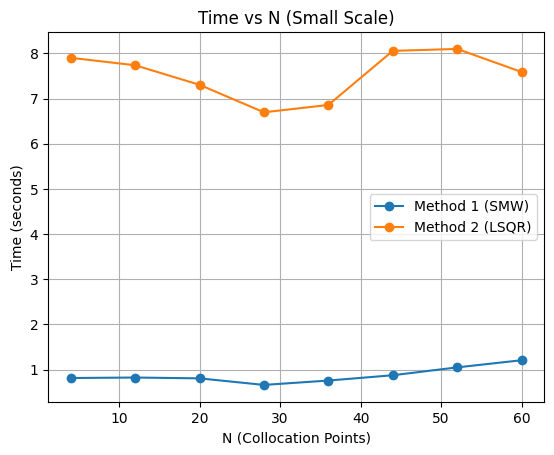

In [41]:
N_vals = [r["N"] for r in results_m1]

time_m1 = [r["total_time"] for r in results_m1]
time_m2 = [r["total_time"] for r in results_m2]

plt.figure()
plt.plot(N_vals, time_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N_vals, time_m2, 'o-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Small Scale)")
plt.legend()
plt.grid()
plt.show()

In [42]:
N_list_large = [100, 300, 500]

results_m1_large = []
results_m2_large = []

for N in N_list_large:
    print(f"\nRunning N = {N}")
    
    res1 = run_method_1(N, steps=800)
    res2 = run_method_2(N, steps=800, lsqr_iters=100)
    
    results_m1_large.append(res1)
    results_m2_large.append(res2)


Running N = 100

Running N = 300

Running N = 500


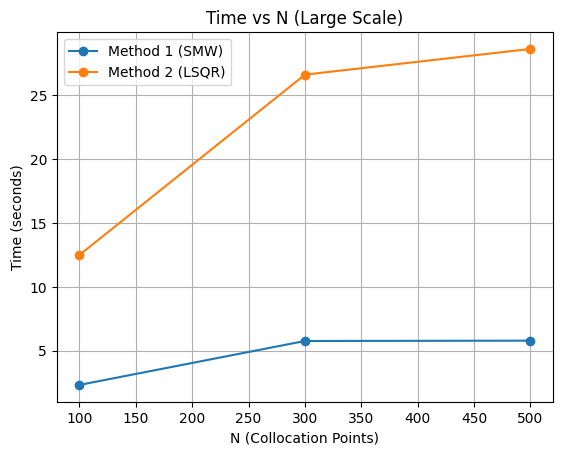

In [43]:
N_vals = [r["N"] for r in results_m1_large]

time_m1 = [r["total_time"] for r in results_m1_large]
time_m2 = [r["total_time"] for r in results_m2_large]

plt.figure()
plt.plot(N_vals, time_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N_vals, time_m2, 'o-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Large Scale)")
plt.legend()
plt.grid()
plt.show()

In [44]:
def extract_metrics(results):
    N_vals = [r["N"] for r in results]
    times = [r["total_time"] for r in results]
    errors = [r["l2_error"] for r in results]
    
    return N_vals, times, errors

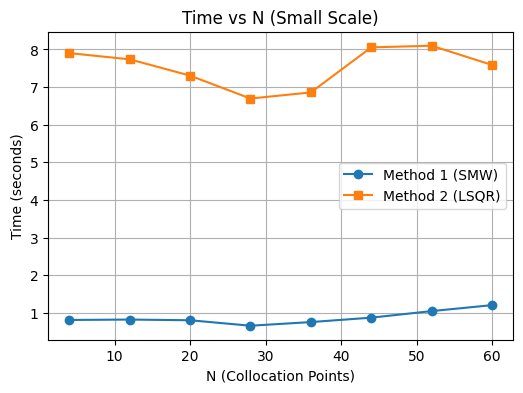

In [45]:
N1, time_m1, err_m1 = extract_metrics(results_m1)
N2, time_m2, err_m2 = extract_metrics(results_m2)

plt.figure(figsize=(6,4))

plt.plot(N1, time_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N2, time_m2, 's-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Small Scale)")
plt.legend()
plt.grid()
plt.show()

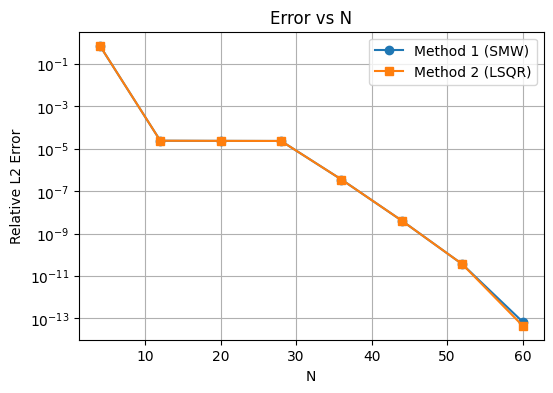

In [46]:
plt.figure(figsize=(6,4))

plt.plot(N1, err_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N2, err_m2, 's-', label="Method 2 (LSQR)")

plt.yscale('log')

plt.xlabel("N")
plt.ylabel("Relative L2 Error")
plt.title("Error vs N")
plt.legend()
plt.grid()
plt.show()

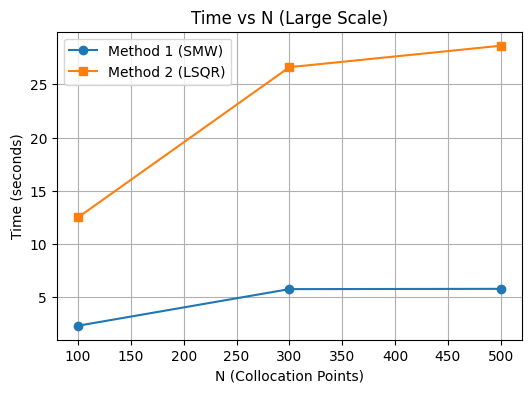

In [47]:
N1L, time_m1L, err_m1L = extract_metrics(results_m1_large)
N2L, time_m2L, err_m2L = extract_metrics(results_m2_large)

plt.figure(figsize=(6,4))

plt.plot(N1L, time_m1L, 'o-', label="Method 1 (SMW)")
plt.plot(N2L, time_m2L, 's-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Large Scale)")
plt.legend()
plt.grid()
plt.show()

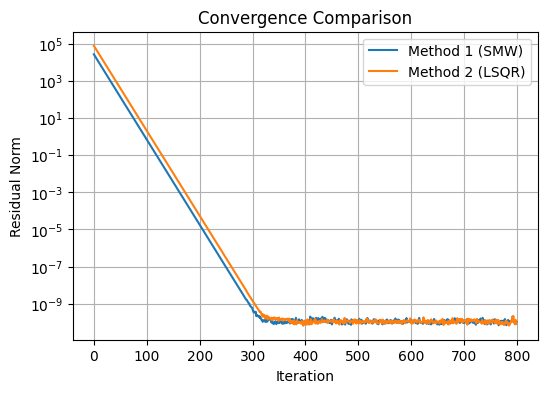

In [48]:
plt.figure(figsize=(6,4))

# pick one N (e.g., last run)
plt.plot(results_m1[-1]["losses"], label="Method 1 (SMW)")
plt.plot(results_m2[-1]["losses"], label="Method 2 (LSQR)")

plt.yscale('log')

plt.xlabel("Iteration")
plt.ylabel("Residual Norm")
plt.title("Convergence Comparison")
plt.legend()
plt.grid()
plt.show()